Missing values in features:
genre               0
rating              0
year                0
runtime             0
director            0
writer              0
star                0
country             0
company             0
release_month       0
decade              0
log_votes           0
log_budget          0
budget_available    0
dtype: int64
Total missing values: 0
Final dataset shape: (5472, 24)
Train shape: (3830, 14)
Validation shape: (821, 14)
Test shape: (821, 14)
Training Linear Regression...
Training Random Forest...
Training XGBoost Baseline...

Validation Results:
               Model    RMSE     MAE      R2
2   XGBoost Baseline  0.6723  0.4925  0.5106
1      Random Forest  0.6871  0.5081  0.4888
0  Linear Regression  0.7579  0.5650  0.3780

Tuning XGBoost...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}

Best Cross-Validation R²:
0.535

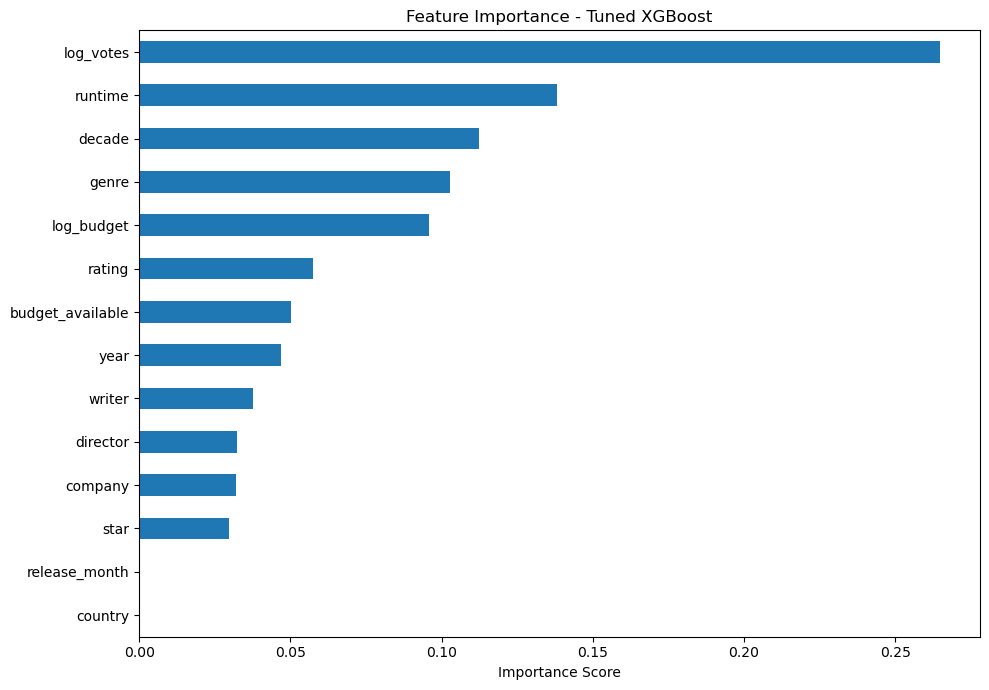

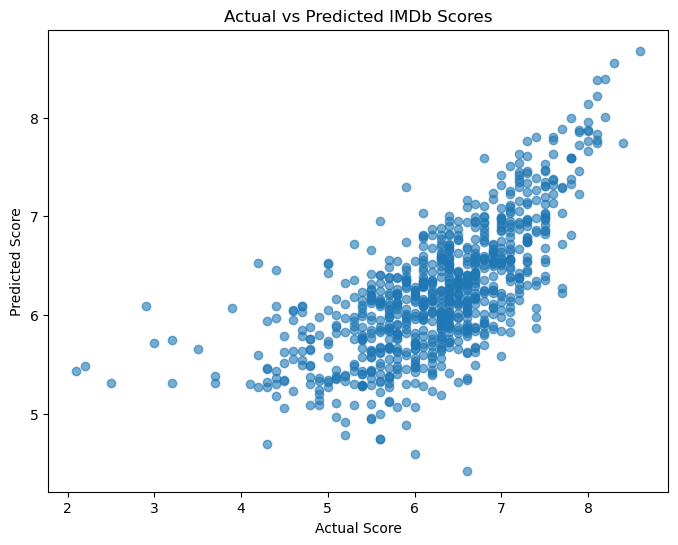


Predictions saved to best_model_predictions.csv
Model comparison saved to model_comparison_results.csv


In [1]:

# ==========================================================
# MOVIE SCORE PREDICTION - MODEL COMPARISON & TUNING
# ==========================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor


# =========================
# 2. LOAD DATA
# =========================

df = pd.read_excel(r"C:\Users\Sahithi\Desktop\Accenture training\movies_cleaned.xlsx")


# =========================
# 3. FEATURE ENGINEERING
# =========================

# Convert release date to datetime
# Invalid values become NaT
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Remove rows where year is missing
df = df.dropna(subset=['year'])

# Convert to integer
df['year'] = df['year'].astype(int)

df['released'] = pd.to_datetime(df['released'], errors='coerce')

# Extract month from release date

df['release_month'] = df['released'].dt.month

# Create decade feature (e.g., 1997 -> 1990)

df['decade'] = (df['year'] // 10) * 10

# Log transform votes and budget

df['log_votes'] = np.log1p(df['votes'].fillna(0))

df['budget_available'] = df['budget'].notnull().astype(int)

df['log_budget'] = np.log1p(df['budget'].fillna(0))




# =========================
# 4. ENCODE CATEGORICAL VARIABLES
# =========================

categorical_cols = [
    'genre',
    'rating',
    'director',
    'writer',
    'star',
    'country',
    'company'
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))


# =========================
# 5. DEFINE FEATURES AND TARGET
# =========================

features = [
    'genre',
    'rating',
    'year',
    'runtime',
    'director',
    'writer',
    'star',
    'country',
    'company',
    'release_month',
    'decade',
    'log_votes',
    'log_budget',
    'budget_available'
]

target = 'score'

# Keep rows with target and features available

target = 'score'

# Keep rows where target exists
df = df[df[target].notnull()].copy()

# Fill missing values in feature columns
df['release_month'] = df['release_month'].fillna(0)
df['runtime'] = df['runtime'].fillna(df['runtime'].median())
df['log_votes'] = df['log_votes'].fillna(0)
df['log_budget'] = df['log_budget'].fillna(0)

# Fill any remaining numeric missing values with median
for col in features:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Verify no missing values remain
print("Missing values in features:")
print(df[features].isnull().sum())

print("Total missing values:",
      df[features].isnull().sum().sum())

print("Final dataset shape:", df.shape)

# =========================
# 6. TEMPORAL SPLIT
# =========================

from sklearn.model_selection import train_test_split

# Prepare full feature matrix and target vector
X = df[features]
y = df[target]

# Step 1: 70% Train, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Step 2: Split temporary set into 15% Validation and 15% Test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print('Train shape:', X_train.shape)
print('Validation shape:', X_valid.shape)
print('Test shape:', X_test.shape)

# Safety check
if X_train.empty or X_valid.empty or X_test.empty:
    raise ValueError('One of the datasets is empty.')


# =========================
# 7. EVALUATION FUNCTION
# =========================

def evaluate_model(model, X, y, model_name):
    preds = model.predict(X)

    rmse = np.sqrt(mean_squared_error(y, preds))
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)

    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }


# =========================
# 8. BASELINE MODEL COMPARISON
# =========================

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost Baseline': XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )
}

results = []

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_valid, y_valid, name)
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)

print('\nValidation Results:')
print(results_df.round(4))


# =========================
# 9. HYPERPARAMETER TUNING
# =========================

print('\nTuning XGBoost...')

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

# Use pre-2019 data for tuning (train + validation)
X_train_valid = pd.concat([X_train, X_valid])
y_train_valid = pd.concat([y_train, y_valid])

# TimeSeries-aware CV would be ideal; cv=3 is a practical approximation.
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_valid, y_train_valid)

print('\nBest Parameters:')
print(grid_search.best_params_)

print('\nBest Cross-Validation R²:')
print(round(grid_search.best_score_, 4))

best_xgb = grid_search.best_estimator_


# =========================
# 10. TEST ON UNSEEN DATA
# =========================

print('\nTesting tuned model on unseen data...')

# The model was trained only on data up to 2018.
# Test data contains movies after 2018 and has never been seen.

test_preds = best_xgb.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
final_mae = mean_absolute_error(y_test, test_preds)
final_r2 = r2_score(y_test, test_preds)

print('\n==============================')
print('FINAL TEST RESULTS (UNSEEN DATA)')
print('==============================')
print('RMSE:', round(final_rmse, 4))
print('MAE :', round(final_mae, 4))
print('R²  :', round(final_r2, 4))


# =========================
# 11. FEATURE IMPORTANCE
# =========================

importance = pd.Series(
    best_xgb.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importance.plot(kind='barh')
plt.title('Feature Importance - Tuned XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


# =========================
# 12. ACTUAL VS PREDICTED
# =========================

plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_preds, alpha=0.6)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted IMDb Scores')
plt.show()


# =========================
# 13. SAVE PREDICTIONS
# =========================

prediction_results = pd.DataFrame({
    'Movie': df.loc[X_test.index, 'name'].values,
    'Actual_Score': y_test.values,
    'Predicted_Score': test_preds
})

prediction_results.to_csv(
    r"C:\Users\Sahithi\Desktop\Accenture training\best_model_predictions.csv",
    index=False
)

print('\nPredictions saved to best_model_predictions.csv')


# =========================
# 14. SAVE MODEL COMPARISON RESULTS
# =========================

results_df.to_csv(r"C:\Users\Sahithi\Desktop\Accenture training\model_comparison_results.csv", index=False)

print('Model comparison saved to model_comparison_results.csv')